# UC4 — EDA: Transacciones Atípicas y Señales de Fraude

> **Objetivo:** Caracterizar las transacciones marcadas con `patron_uso_atipico=True`, comparar su perfil con las normales y correlacionar con conversaciones de fraude en Havi.  
> **Autor:** Fernando Haro · datamoles — Datathon Hey 2026  
> **Dependencias:** `01_eda_carga_datos.ipynb`

---

### Tareas cubiertas
- [x] % de transacciones con `patron_uso_atipico=True`
- [x] Comparar monto promedio atípico vs normal
- [x] Distribución horaria de transacciones atípicas
- [x] % de atípicas que son `es_internacional=True`
- [x] Top ciudades: atípicas vs ciudad de residencia
- [x] Distribución por `tipo_operacion` en atípicas
- [x] Búsqueda de conversaciones sobre fraude / cargos no reconocidos
- [x] Usuarios con `patron_uso_atipico=True` en clientes con transacciones atípicas

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FIGSIZE = (12, 5)

BASE_TXN  = Path(r'/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones')
BASE_CONV = Path(r'/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_dataset_conversaciones 1/dataset_conversaciones')

print('Paths OK:', BASE_TXN.exists(), BASE_CONV.exists())

Paths OK: True True


## 1 · Carga de datos

In [2]:
df_tx = pd.read_csv(
    BASE_TXN / 'hey_transacciones.csv',
    dtype={'transaccion_id': str, 'user_id': str, 'producto_id': str},
    parse_dates=['fecha_hora']
)
df_tx.drop(columns=[c for c in df_tx.columns if c == 'es_dato_sintetico'], inplace=True)

df_clientes = pd.read_csv(
    BASE_TXN / 'hey_clientes.csv',
    dtype={'user_id': str}
)

df_convs = pd.read_parquet(BASE_CONV / 'dataset_50k_anonymized.parquet')
df_convs['date'] = pd.to_datetime(df_convs['date'], format='mixed')

print(f'Transacciones : {len(df_tx):,}')
print(f'Clientes      : {len(df_clientes):,}')
print(f'Conversaciones: {len(df_convs):,}')

Transacciones : 802,384
Clientes      : 15,025
Conversaciones: 49,999


## 2 · Segmentación: atípicas vs normales

In [3]:
atipicas = df_tx[df_tx['patron_uso_atipico'] == True].copy()
normales  = df_tx[df_tx['patron_uso_atipico'] == False].copy()

n_total   = len(df_tx)
n_atip    = len(atipicas)
pct_atip  = n_atip / n_total * 100

print(f'Total transacciones      : {n_total:>10,}')
print(f'Atípicas (True)          : {n_atip:>10,}  ({pct_atip:.2f}%)')
print(f'Normales (False)         : {len(normales):>10,}  ({100-pct_atip:.2f}%)')

Total transacciones      :    802,384
Atípicas (True)          :     41,492  (5.17%)
Normales (False)         :    760,892  (94.83%)


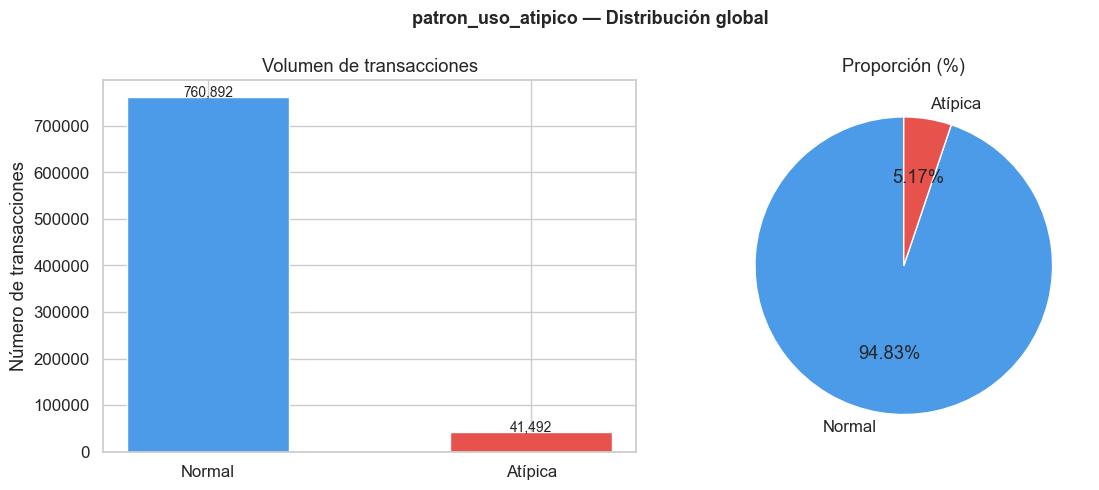

In [4]:
# Visualización del volumen
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

labels  = ['Normal', 'Atípica']
counts  = [len(normales), n_atip]
colors  = ['#4C9BE8', '#E8524C']

axes[0].bar(labels, counts, color=colors, width=0.5)
axes[0].set_title('Volumen de transacciones')
axes[0].set_ylabel('Número de transacciones')
for i, v in enumerate(counts):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie([100 - pct_atip, pct_atip],
            labels=['Normal', 'Atípica'],
            autopct='%1.2f%%',
            colors=colors,
            startangle=90)
axes[1].set_title('Proporción (%)')

plt.suptitle('patron_uso_atipico — Distribución global', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uc4_fig1_volumen_atipicas.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Comparación de montos: atípicas vs normales

In [5]:
monto_stats = pd.DataFrame({
    'Atípica': atipicas['monto'].describe(),
    'Normal' : normales['monto'].describe()
}).round(2)

print('=== Estadísticas de monto (MXN) ===')
print(monto_stats.to_string())

ratio_media   = atipicas['monto'].mean()   / normales['monto'].mean()
ratio_mediana = atipicas['monto'].median() / normales['monto'].median()
print(f'\nRatio media atípica/normal  : {ratio_media:.2f}x')
print(f'Ratio mediana atípica/normal: {ratio_mediana:.2f}x')

=== Estadísticas de monto (MXN) ===
        Atípica     Normal
count  41492.00  760892.00
mean    5784.53    6126.16
std     9420.31    9909.74
min        5.02       5.01
25%      516.72     541.26
50%     1615.05    1748.14
75%     6310.00    7072.72
max    60000.00   79511.30

Ratio media atípica/normal  : 0.94x
Ratio mediana atípica/normal: 0.92x


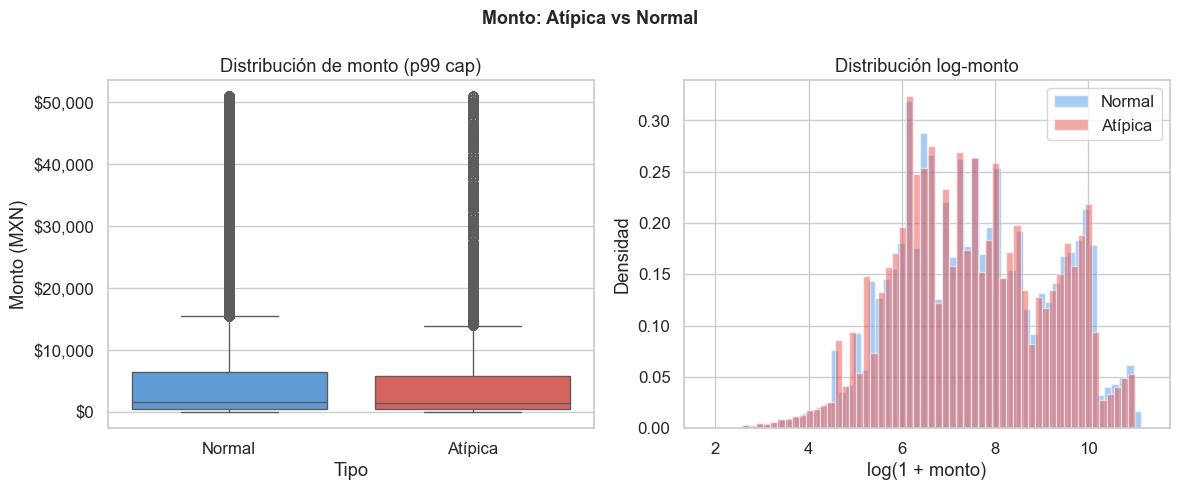

In [6]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Boxplot comparativo (sin outliers extremos para visualización)
p99 = df_tx['monto'].quantile(0.99)
plot_data = df_tx[df_tx['monto'] <= p99].copy()
plot_data['Tipo'] = plot_data['patron_uso_atipico'].map({True: 'Atípica', False: 'Normal'})

sns.boxplot(data=plot_data, x='Tipo', y='monto', palette={'Atípica': '#E8524C', 'Normal': '#4C9BE8'}, ax=axes[0])
axes[0].set_title('Distribución de monto (p99 cap)')
axes[0].set_ylabel('Monto (MXN)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# KDE log-scale
log_atip = np.log1p(atipicas['monto'])
log_norm = np.log1p(normales['monto'])
axes[1].hist(log_norm,  bins=60, alpha=0.5, color='#4C9BE8', label='Normal',  density=True)
axes[1].hist(log_atip,  bins=60, alpha=0.5, color='#E8524C', label='Atípica', density=True)
axes[1].set_xlabel('log(1 + monto)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución log-monto')
axes[1].legend()

plt.suptitle('Monto: Atípica vs Normal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uc4_fig2_monto_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Distribución horaria de transacciones atípicas

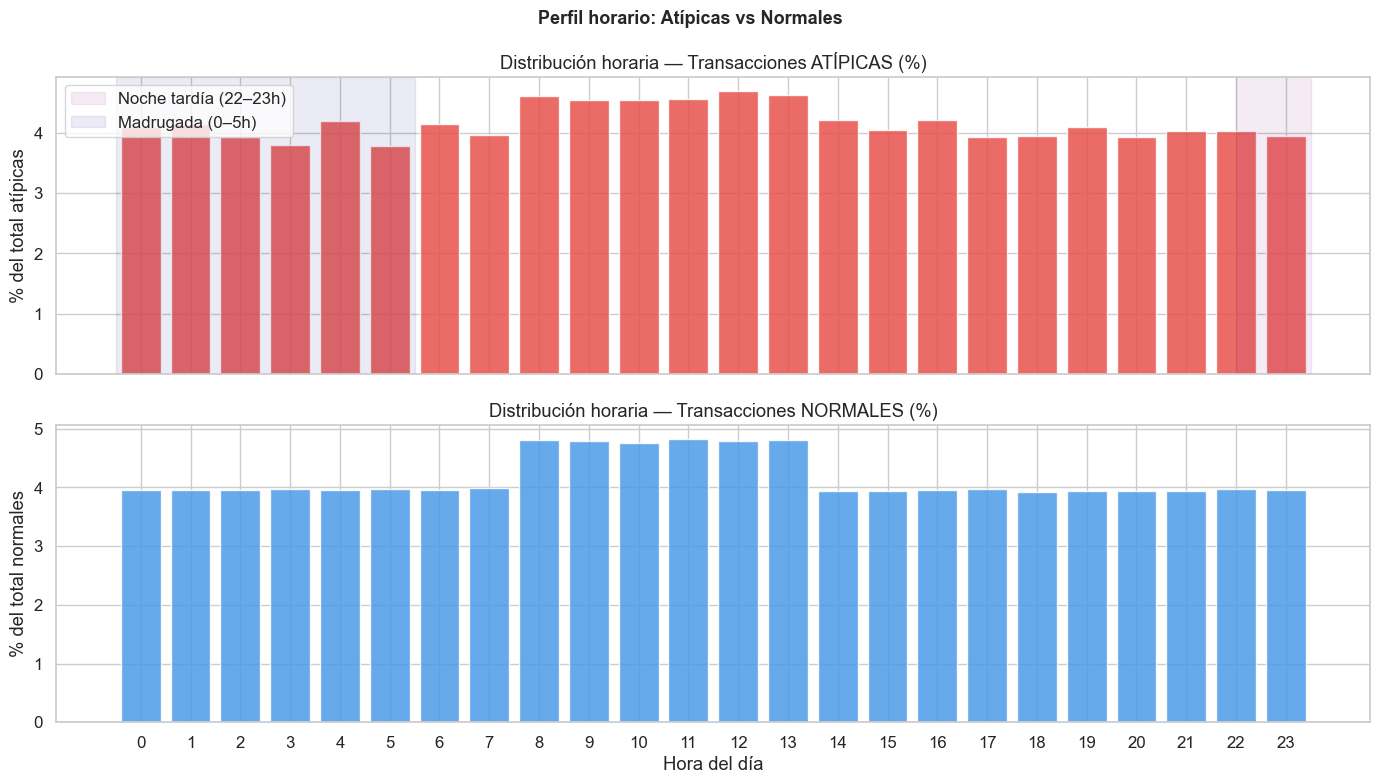

Atípicas nocturnas (22–23h + 0–5h): 13,244  (31.92% de atípicas)
Normales nocturnas (22–23h + 0–5h): 241,159  (31.69% de normales)
Ratio nocturno atíp/normal: 1.01x


In [7]:
hora_atip = atipicas['hora_del_dia'].value_counts().sort_index()
hora_norm = normales['hora_del_dia'].value_counts().sort_index()

# Normalizar a proporción para comparación justa
hora_atip_pct = hora_atip / hora_atip.sum() * 100
hora_norm_pct = hora_norm / hora_norm.sum() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

horas = range(24)
axes[0].bar(horas, [hora_atip_pct.get(h, 0) for h in horas], color='#E8524C', alpha=0.85)
axes[0].set_title('Distribución horaria — Transacciones ATÍPICAS (%)')
axes[0].set_ylabel('% del total atípicas')
axes[0].axvspan(22, 23.5, alpha=0.08, color='purple', label='Noche tardía (22–23h)')
axes[0].axvspan(-0.5, 5.5, alpha=0.08, color='navy', label='Madrugada (0–5h)')
axes[0].legend()

axes[1].bar(horas, [hora_norm_pct.get(h, 0) for h in horas], color='#4C9BE8', alpha=0.85)
axes[1].set_title('Distribución horaria — Transacciones NORMALES (%)')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('% del total normales')

plt.xticks(range(24))
plt.suptitle('Perfil horario: Atípicas vs Normales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uc4_fig3_distribucion_horaria.png', dpi=150, bbox_inches='tight')
plt.show()

# Cuantificar transacciones nocturnas/madrugada
atip_nocturnas = atipicas[atipicas['hora_del_dia'].between(22, 23) | atipicas['hora_del_dia'].between(0, 5)]
pct_noc_atip = len(atip_nocturnas) / len(atipicas) * 100
norm_nocturnas = normales[normales['hora_del_dia'].between(22, 23) | normales['hora_del_dia'].between(0, 5)]
pct_noc_norm = len(norm_nocturnas) / len(normales) * 100

print(f'Atípicas nocturnas (22–23h + 0–5h): {len(atip_nocturnas):,}  ({pct_noc_atip:.2f}% de atípicas)')
print(f'Normales nocturnas (22–23h + 0–5h): {len(norm_nocturnas):,}  ({pct_noc_norm:.2f}% de normales)')
print(f'Ratio nocturno atíp/normal: {pct_noc_atip/pct_noc_norm:.2f}x')

## 5 · Internacionalidad en transacciones atípicas

In [8]:
pct_intl_atip = atipicas['es_internacional'].mean() * 100
pct_intl_norm = normales['es_internacional'].mean() * 100

print(f'% internacionales en ATÍPICAS : {pct_intl_atip:.2f}%')
print(f'% internacionales en NORMALES : {pct_intl_norm:.2f}%')
print(f'Lift internacional atíp/normal: {pct_intl_atip/pct_intl_norm:.2f}x')

# Señal combinada: internacional Y nocturna
atip_intl_noc = atipicas[
    (atipicas['es_internacional'] == True) &
    (atipicas['hora_del_dia'].between(22, 23) | atipicas['hora_del_dia'].between(0, 5))
]
pct_intl_noc = len(atip_intl_noc) / len(atipicas) * 100
print(f'\n🚨 Atípicas internacionales Y nocturnas: {len(atip_intl_noc):,}  ({pct_intl_noc:.2f}% de atípicas)')

% internacionales en ATÍPICAS : 4.82%
% internacionales en NORMALES : 5.00%
Lift internacional atíp/normal: 0.97x

🚨 Atípicas internacionales Y nocturnas: 600  (1.45% de atípicas)


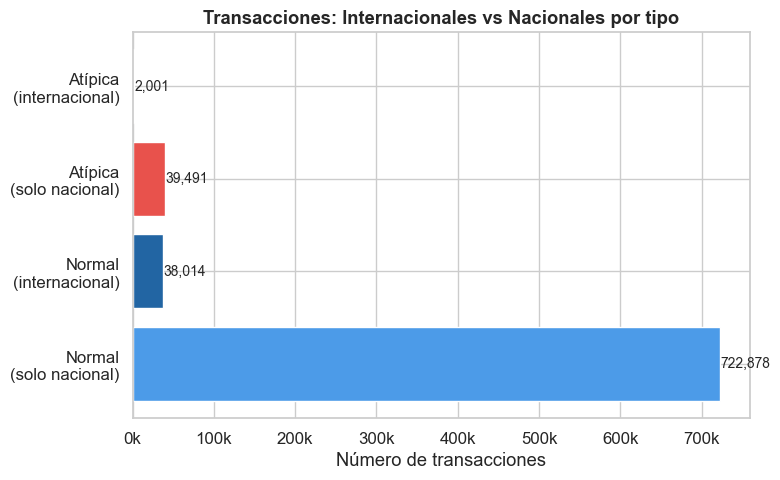

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

categorias = ['Normal\n(solo nacional)', 'Normal\n(internacional)', 'Atípica\n(solo nacional)', 'Atípica\n(internacional)']
valores = [
    len(normales[normales['es_internacional'] == False]),
    len(normales[normales['es_internacional'] == True]),
    len(atipicas[atipicas['es_internacional'] == False]),
    len(atipicas[atipicas['es_internacional'] == True]),
]
colores = ['#4C9BE8', '#2265A3', '#E8524C', '#991E1A']

bars = ax.barh(categorias, valores, color=colores)
for bar, val in zip(bars, valores):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Número de transacciones')
ax.set_title('Transacciones: Internacionales vs Nacionales por tipo', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('uc4_fig4_internacional.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Top ciudades: atípicas vs ciudad de residencia

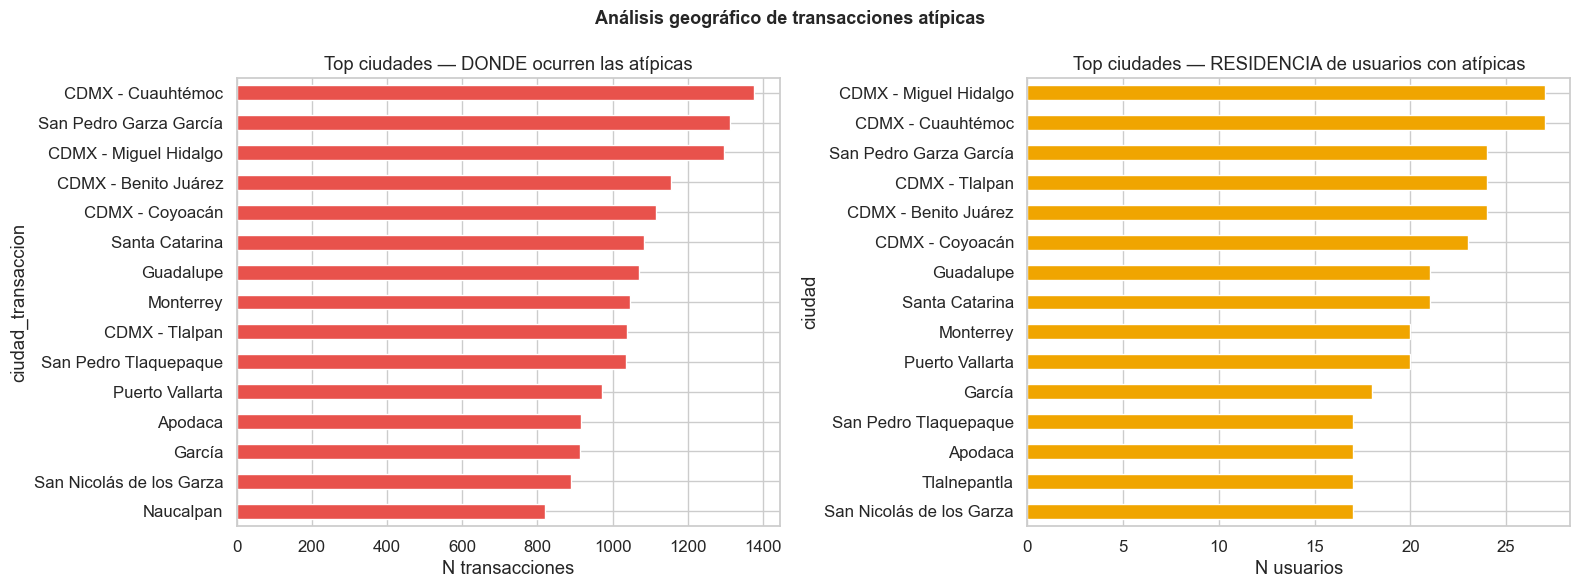

Atípicas en ciudad diferente a residencia: 12.5%


In [10]:
# Top ciudades de las transacciones atípicas
top_ciudades_atip = (
    atipicas['ciudad_transaccion']
    .dropna()
    .value_counts()
    .head(15)
)

# Top ciudades de los clientes con transacciones atípicas
user_ids_atip = atipicas['user_id'].unique()
residencia_atip = (
    df_clientes[df_clientes['user_id'].isin(user_ids_atip)]['ciudad']
    .dropna()
    .value_counts()
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_ciudades_atip.plot(kind='barh', ax=axes[0], color='#E8524C')
axes[0].invert_yaxis()
axes[0].set_title('Top ciudades — DONDE ocurren las atípicas')
axes[0].set_xlabel('N transacciones')

residencia_atip.plot(kind='barh', ax=axes[1], color='#F0A500')
axes[1].invert_yaxis()
axes[1].set_title('Top ciudades — RESIDENCIA de usuarios con atípicas')
axes[1].set_xlabel('N usuarios')

plt.suptitle('Análisis geográfico de transacciones atípicas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uc4_fig5_ciudades.png', dpi=150, bbox_inches='tight')
plt.show()

# Mismatch: ciudad de la txn atípica != ciudad de residencia del usuario
atip_geo = atipicas[['user_id', 'ciudad_transaccion']].dropna().merge(
    df_clientes[['user_id', 'ciudad']].dropna(), on='user_id', how='inner'
)
atip_geo['ciudad_distinta'] = atip_geo['ciudad_transaccion'].str.lower() != atip_geo['ciudad'].str.lower()
pct_distinta = atip_geo['ciudad_distinta'].mean() * 100
print(f'Atípicas en ciudad diferente a residencia: {pct_distinta:.1f}%')

## 7 · Distribución por tipo_operacion en atípicas

In [11]:
tipo_atip = atipicas['tipo_operacion'].value_counts(normalize=True).mul(100).rename('Atípica (%)')
tipo_norm = normales['tipo_operacion'].value_counts(normalize=True).mul(100).rename('Normal (%)')

tipo_df = pd.concat([tipo_atip, tipo_norm], axis=1).fillna(0).round(2)
tipo_df['Lift'] = (tipo_df['Atípica (%)'] / tipo_df['Normal (%)']).round(2)
tipo_df.sort_values('Lift', ascending=False, inplace=True)

print('=== Tipo de operación: % y lift atípica vs normal ===')
print(tipo_df.to_string())

=== Tipo de operación: % y lift atípica vs normal ===
                   Atípica (%)  Normal (%)  Lift
tipo_operacion                                  
deposito_farmacia         0.46        0.39  1.18
cashback                  1.88        1.77  1.06
cargo_recurrente          8.75        8.36  1.05
deposito_oxxo             3.01        2.88  1.05
pago_credito              6.57        6.43  1.02
compra                   40.21       39.80  1.01
transf_salida            11.23       11.23  1.00
retiro_cajero             4.84        4.86  1.00
transf_entrada           11.31       11.50  0.98
pago_servicio             5.88        6.06  0.97
retiro_inversion          1.35        1.48  0.91
abono_inversion           4.51        5.24  0.86


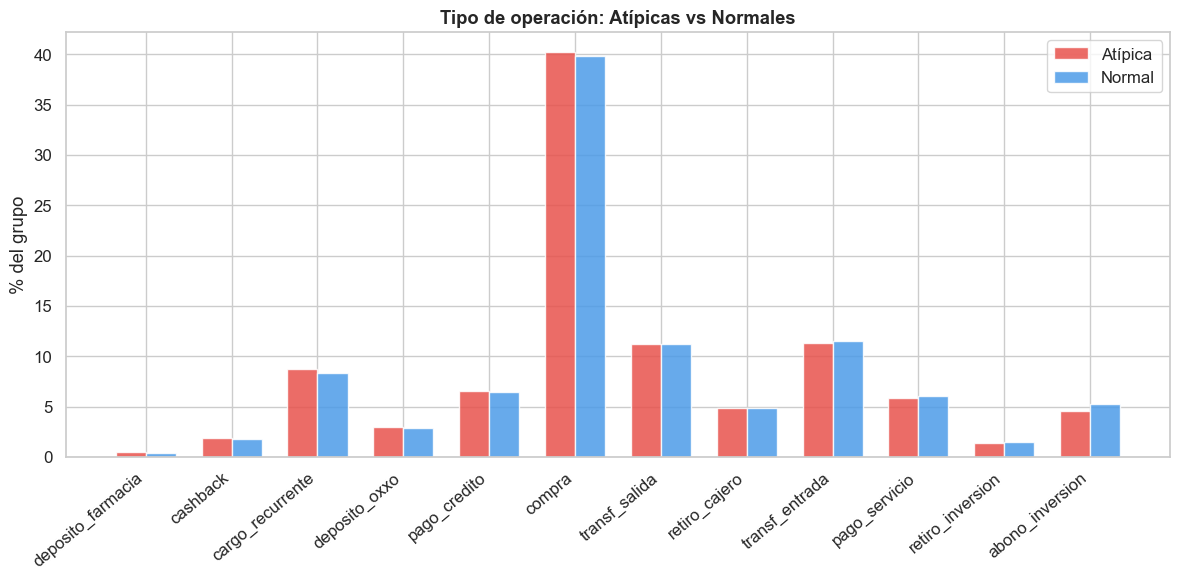

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

operaciones = tipo_df.index
x = np.arange(len(operaciones))
width = 0.35

ax.bar(x - width/2, tipo_df['Atípica (%)'], width, label='Atípica', color='#E8524C', alpha=0.85)
ax.bar(x + width/2, tipo_df['Normal (%)'],  width, label='Normal',  color='#4C9BE8', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(operaciones, rotation=40, ha='right')
ax.set_ylabel('% del grupo')
ax.set_title('Tipo de operación: Atípicas vs Normales', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('uc4_fig6_tipo_operacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Estatus de transacciones atípicas

In [13]:
estatus_atip = atipicas['estatus'].value_counts(normalize=True).mul(100).rename('Atípica (%)')
estatus_norm = normales['estatus'].value_counts(normalize=True).mul(100).rename('Normal (%)')

estatus_df = pd.concat([estatus_atip, estatus_norm], axis=1).fillna(0).round(2)
estatus_df['Lift'] = (estatus_df['Atípica (%)'] / estatus_df['Normal (%)']).round(2)
print('=== Estatus de la transacción ===')
print(estatus_df.to_string())

=== Estatus de la transacción ===
              Atípica (%)  Normal (%)  Lift
estatus                                    
completada          93.27       93.25  1.00
no_procesada         3.35        3.31  1.01
en_disputa           2.36        2.37  1.00
revertida            1.02        1.06  0.96


## 9 · Perfil estadístico completo: atípica vs normal

In [14]:
def perfil(df, label):
    return {
        'Grupo': label,
        'N transacciones': len(df),
        'Monto media (MXN)': df['monto'].mean().round(2),
        'Monto mediana (MXN)': df['monto'].median().round(2),
        'Monto std': df['monto'].std().round(2),
        'Monto p95': df['monto'].quantile(0.95).round(2),
        '% internacional': (df['es_internacional'].mean() * 100).round(2),
        '% nocturna (0-5h + 22-23h)': (
            (df['hora_del_dia'].between(0, 5) | df['hora_del_dia'].between(22, 23)).mean() * 100
        ).round(2),
        '% en_disputa': (df['estatus'].eq('en_disputa').mean() * 100).round(2),
        '% no_procesada': (df['estatus'].eq('no_procesada').mean() * 100).round(2),
        '% intento_numero > 1': (df['intento_numero'].gt(1).mean() * 100).round(2),
    }

resumen = pd.DataFrame([perfil(atipicas, 'Atípica'), perfil(normales, 'Normal')]).set_index('Grupo')
print('=== PERFIL ESTADÍSTICO COMPLETO ===')
print(resumen.T.to_string())

=== PERFIL ESTADÍSTICO COMPLETO ===
Grupo                        Atípica     Normal
N transacciones             41492.00  760892.00
Monto media (MXN)            5784.53    6126.16
Monto mediana (MXN)          1615.05    1748.14
Monto std                    9420.31    9909.74
Monto p95                   23410.00   24010.00
% internacional                 4.82       5.00
% nocturna (0-5h + 22-23h)     31.92      31.69
% en_disputa                    2.36       2.37
% no_procesada                  3.35       3.31
% intento_numero > 1            2.29       2.20


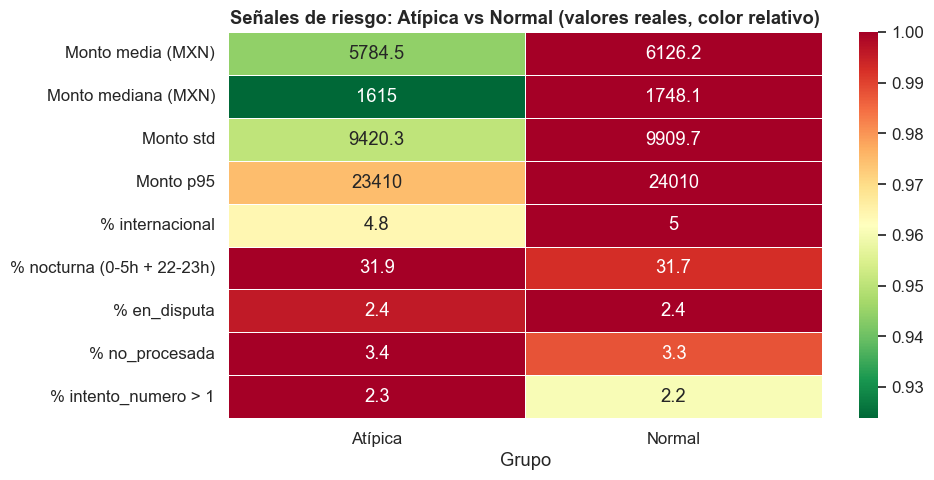

In [15]:
# Heatmap de señales clave
fig, ax = plt.subplots(figsize=(10, 5))

heatmap_data = resumen.T.drop('N transacciones')
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)  # escalar 0–1 por fila

sns.heatmap(
    heatmap_norm,
    annot=heatmap_data.round(1),
    fmt='g',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Señales de riesgo: Atípica vs Normal (valores reales, color relativo)', fontweight='bold')
plt.tight_layout()
plt.savefig('uc4_fig7_heatmap_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Conversaciones sobre fraude y cargos no reconocidos

In [16]:
PATRON_FRAUDE = r'fraude|cargo\s+no\s+reconoc|no\s+reconoc|bloquear\s+tarjeta|bloquear|no fui yo|no lo hice|cobro\s+extran|robo|clonaron|clonada|reportar\s+cargo|desconoc'

fraude_convs = df_convs[
    df_convs['input'].str.contains(PATRON_FRAUDE, case=False, na=False, regex=True)
].copy()

print(f'Total turnos sobre fraude/cargo no reconocido: {len(fraude_convs):,}')
print(f'Conversaciones únicas afectadas             : {fraude_convs["conv_id"].nunique():,}')
print(f'Usuarios únicos afectados                   : {fraude_convs["user_id"].nunique():,}')
print(f'% del total de turnos                       : {len(fraude_convs)/len(df_convs)*100:.2f}%')

Total turnos sobre fraude/cargo no reconocido: 843
Conversaciones únicas afectadas             : 793
Usuarios únicos afectados                   : 703
% del total de turnos                       : 1.69%


In [17]:
# Desglose por sub-patrón
subpatrones = {
    'fraude'            : r'fraude',
    'cargo no reconocido': r'cargo\s+no\s+reconoc|no\s+reconoc|cobro\s+extran|desconoc',
    'bloquear tarjeta'  : r'bloquear',
    'no fui yo / no lo hice': r'no fui yo|no lo hice',
    'robo / clonación'  : r'robo|clonaron|clonada',
    'reportar cargo'    : r'reportar\s+cargo',
}

desglose = {}
for nombre, pat in subpatrones.items():
    n = df_convs['input'].str.contains(pat, case=False, na=False, regex=True).sum()
    desglose[nombre] = n

desglose_df = pd.Series(desglose).sort_values(ascending=False)
print('\n=== Desglose por sub-patrón ===')
for k, v in desglose_df.items():
    print(f'  {k:<30}: {v:,} turnos')


=== Desglose por sub-patrón ===
  cargo no reconocido           : 504 turnos
  bloquear tarjeta              : 228 turnos
  robo / clonación              : 77 turnos
  fraude                        : 35 turnos
  reportar cargo                : 18 turnos
  no fui yo / no lo hice        : 3 turnos


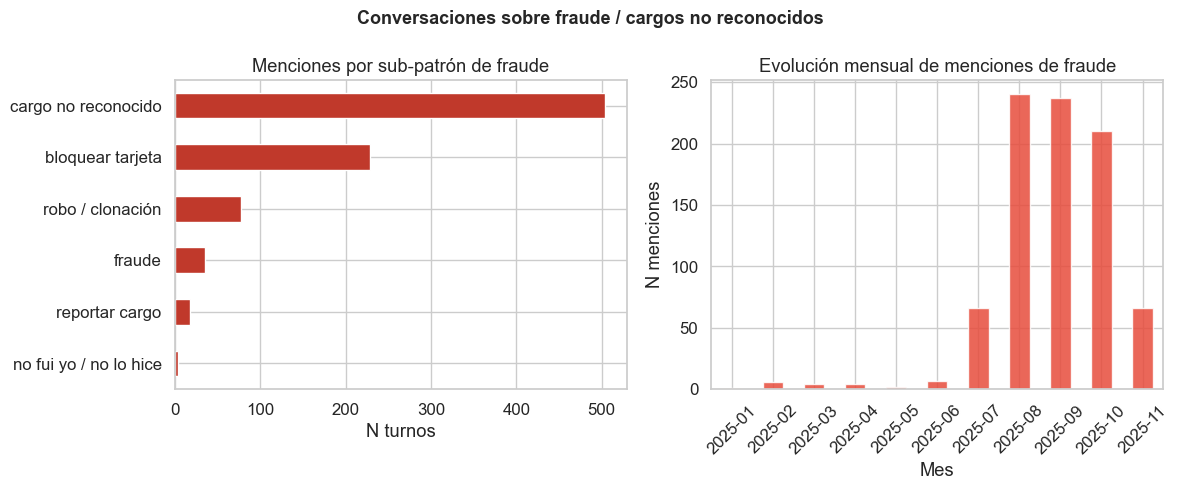

In [18]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

desglose_df.plot(kind='barh', ax=axes[0], color='#C0392B')
axes[0].invert_yaxis()
axes[0].set_xlabel('N turnos')
axes[0].set_title('Menciones por sub-patrón de fraude')

# Distribución temporal de menciones
fraude_mes = fraude_convs.groupby(fraude_convs['date'].dt.to_period('M')).size()
fraude_mes.index = fraude_mes.index.astype(str)
fraude_mes.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.85)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('N menciones')
axes[1].set_title('Evolución mensual de menciones de fraude')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Conversaciones sobre fraude / cargos no reconocidos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uc4_fig8_fraude_convs.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Muestra de mensajes para validación cualitativa
print('=== Muestra de inputs de fraude ===')
for i, row in fraude_convs[['input', 'output']].head(8).iterrows():
    print(f'\n[{i}] USER: {row["input"][:200]}')
    print(f'    HAVI: {str(row["output"])[:200]}')

=== Muestra de inputs de fraude ===

[212] USER: No hay opción cargo no reconocido
    HAVI: Lamento escuchar eso. Para aclarar un cargo no reconocido en tu Tarjeta de Débito Hey, asegúrate de seguir estos pasos:

1. Inicia sesión en tu app Hey Banco.
2. Ve a la sección 'Cuentas'.
3. Seleccio

[250] USER: Movimiento no reconocido
    HAVI: Lamento escuchar eso. Si tienes un movimiento no reconocido en tu cuenta, te recomiendo que revises tus movimientos recientes en la app Hey. Para hacerlo, solo abre la app, ve a 'Cuentas', selecciona 

[251] USER: Quiero reportar un cargo no reconocido
    HAVI: Claro que puedo ayudarte. Para reportar un movimiento no reconocido en tu Tarjeta de Débito Hey, puedes seguir estos pasos:

1. Abre la app Hey Banco y asegúrate de haber iniciado sesión.
2. Ve a 'Cue

[344] USER: Cargos no reconocidos
    HAVI: Claro! Si tienes un cargo no reconocido en tu cuenta, puedes reportarlo de la siguiente manera:

1. **Desde la app Hey Banco**: Ve a la sección de 'C

## 11 · Cruce: usuarios con patron_uso_atipico en clientes ↔ transacciones atípicas

In [20]:
# Usuarios marcados como atípicos en hey_clientes
cli_atip = df_clientes[df_clientes['patron_uso_atipico'] == True]['user_id']
print(f'Usuarios con patron_uso_atipico=True en clientes: {len(cli_atip):,}')

# Usuarios que tienen AL MENOS 1 transacción atípica
tx_atip_users = set(atipicas['user_id'].unique())
print(f'Usuarios con ≥1 transacción atípica            : {len(tx_atip_users):,}')

# Intersección
interseccion = set(cli_atip) & tx_atip_users
print(f'Usuarios atípicos en AMBAS tablas              : {len(interseccion):,}')
print(f'  (% de cli_atip con txn atípica)              : {len(interseccion)/len(cli_atip)*100:.1f}%')
print(f'  (% de tx_atip con flag en clientes)          : {len(interseccion)/len(tx_atip_users)*100:.1f}%')

# Usuarios con txn atípica pero NO flagueados en clientes
solo_tx_atip = tx_atip_users - set(cli_atip)
print(f'\nUsuarios con txn atípica pero SIN flag en clientes: {len(solo_tx_atip):,}')

# Usuarios flagueados en clientes pero SIN txn atípica
solo_cli_atip = set(cli_atip) - tx_atip_users
print(f'Usuarios con flag en clientes pero SIN txn atípica: {len(solo_cli_atip):,}')

Usuarios con patron_uso_atipico=True en clientes: 763
Usuarios con ≥1 transacción atípica            : 763
Usuarios atípicos en AMBAS tablas              : 763
  (% de cli_atip con txn atípica)              : 100.0%
  (% de tx_atip con flag en clientes)          : 100.0%

Usuarios con txn atípica pero SIN flag en clientes: 0
Usuarios con flag en clientes pero SIN txn atípica: 0


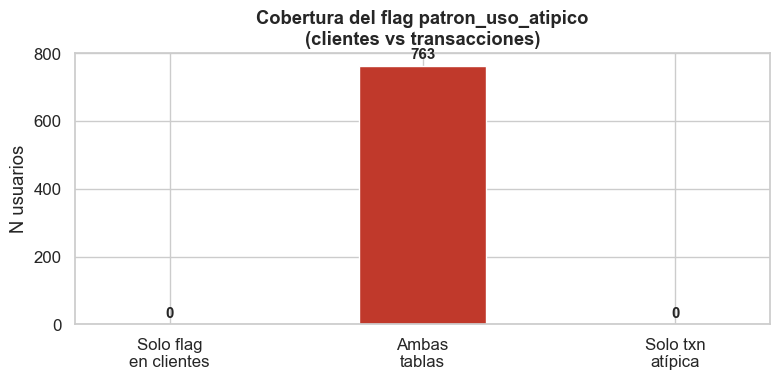

In [21]:
# Diagrama de Venn simplificado con barras
fig, ax = plt.subplots(figsize=(8, 4))

categorias = [
    'Solo flag\nen clientes',
    'Ambas\ntablas',
    'Solo txn\natípica'
]
valores = [len(solo_cli_atip), len(interseccion), len(solo_tx_atip)]
colores = ['#F39C12', '#C0392B', '#8E44AD']

bars = ax.bar(categorias, valores, color=colores, width=0.5)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('N usuarios')
ax.set_title('Cobertura del flag patron_uso_atipico\n(clientes vs transacciones)', fontweight='bold')
plt.tight_layout()
plt.savefig('uc4_fig9_cobertura_flag.png', dpi=150, bbox_inches='tight')
plt.show()

## 12 · Cruce: usuarios con fraude conversacional ↔ transacciones atípicas

In [22]:
fraude_users = set(fraude_convs['user_id'].unique())
print(f'Usuarios que mencionan fraude en Havi       : {len(fraude_users):,}')

# Cruce con usuarios que tienen txn atípicas
fraude_con_atip = fraude_users & tx_atip_users
print(f'De ellos, con ≥1 txn atípica               : {len(fraude_con_atip):,}  ({len(fraude_con_atip)/len(fraude_users)*100:.1f}%)')

# Cruce con flag en clientes
fraude_con_flag_cli = fraude_users & set(cli_atip)
print(f'De ellos, con flag en hey_clientes         : {len(fraude_con_flag_cli):,}  ({len(fraude_con_flag_cli)/len(fraude_users)*100:.1f}%)')

Usuarios que mencionan fraude en Havi       : 703
De ellos, con ≥1 txn atípica               : 42  (6.0%)
De ellos, con flag en hey_clientes         : 42  (6.0%)


## 13 · Señal combinada: internacional + nocturna (criterio de riesgo máximo)

In [23]:
df_tx['es_nocturna'] = df_tx['hora_del_dia'].between(0, 5) | df_tx['hora_del_dia'].between(22, 23)

signal_table = df_tx.groupby('patron_uso_atipico').agg(
    total=('transaccion_id', 'count'),
    pct_internacional=('es_internacional', lambda x: x.mean() * 100),
    pct_nocturna=('es_nocturna', lambda x: x.mean() * 100),
).round(2)

signal_table['pct_intl_y_nocturna'] = df_tx.groupby('patron_uso_atipico').apply(
    lambda g: ((g['es_internacional'] == True) & (g['es_nocturna'] == True)).mean() * 100
).round(2).values

signal_table.index = signal_table.index.map({True: 'Atípica', False: 'Normal'})
print('=== SEÑAL COMBINADA: Internacional + Nocturna ===')
print(signal_table.to_string())

=== SEÑAL COMBINADA: Internacional + Nocturna ===
                     total  pct_internacional  pct_nocturna  pct_intl_y_nocturna
patron_uso_atipico                                                              
Normal              760892               5.00         31.69                 1.59
Atípica              41492               4.82         31.92                 1.45


## 14 · Resumen ejecutivo UC4

In [24]:
print('=' * 60)
print('RESUMEN EJECUTIVO — UC4: Transacciones Atípicas')
print('=' * 60)

pct_intl_atip_val  = atipicas['es_internacional'].mean() * 100
pct_noc_atip_val   = ((atipicas['hora_del_dia'].between(0,5)) | (atipicas['hora_del_dia'].between(22,23))).mean() * 100
pct_intl_noc_atip  = ((atipicas['es_internacional']==True) & ((atipicas['hora_del_dia'].between(0,5)) | (atipicas['hora_del_dia'].between(22,23)))).mean() * 100

print(f"""
VOLUMEN
  Transacciones atípicas         : {n_atip:,} ({pct_atip:.2f}% del total)
  Usuarios con ≥1 txn atípica    : {len(tx_atip_users):,}

PERFIL MONETARIO
  Monto medio atípicas           : ${atipicas['monto'].mean():,.0f} MXN
  Monto medio normales           : ${normales['monto'].mean():,.0f} MXN
  Ratio media atíp/normal        : {atipicas['monto'].mean()/normales['monto'].mean():.2f}x
  Monto mediana atípicas         : ${atipicas['monto'].median():,.0f} MXN
  Monto mediana normales         : ${normales['monto'].median():,.0f} MXN

SEÑALES DE RIESGO
  % atípicas internacionales     : {pct_intl_atip_val:.2f}%
  % normales internacionales     : {pct_intl_norm:.2f}%
  % atípicas nocturnas           : {pct_noc_atip_val:.2f}%
  % atípicas INTL + nocturnas    : {pct_intl_noc_atip:.2f}%
  % atípicas en_disputa          : {(atipicas['estatus']=='en_disputa').mean()*100:.2f}%

CONVERSACIONES DE FRAUDE
  Turnos con mención de fraude   : {len(fraude_convs):,}
  Conversaciones únicas          : {fraude_convs['conv_id'].nunique():,}
  Usuarios únicos                : {fraude_convs['user_id'].nunique():,}
  Con txn atípica cruzada        : {len(fraude_con_atip):,} ({len(fraude_con_atip)/len(fraude_users)*100:.1f}%)

COBERTURA DEL FLAG
  Clientes con flag atípico      : {len(cli_atip):,}
  De ellos con txn atípica       : {len(interseccion):,} ({len(interseccion)/len(cli_atip)*100:.1f}%)
  Usuarios solo en txn (sin flag cli): {len(solo_tx_atip):,}
""")

RESUMEN EJECUTIVO — UC4: Transacciones Atípicas



VOLUMEN
  Transacciones atípicas         : 41,492 (5.17% del total)
  Usuarios con ≥1 txn atípica    : 763

PERFIL MONETARIO
  Monto medio atípicas           : $5,785 MXN
  Monto medio normales           : $6,126 MXN
  Ratio media atíp/normal        : 0.94x
  Monto mediana atípicas         : $1,615 MXN
  Monto mediana normales         : $1,748 MXN

SEÑALES DE RIESGO
  % atípicas internacionales     : 4.82%
  % normales internacionales     : 5.00%
  % atípicas nocturnas           : 31.92%
  % atípicas INTL + nocturnas    : 1.45%
  % atípicas en_disputa          : 2.36%

CONVERSACIONES DE FRAUDE
  Turnos con mención de fraude   : 843
  Conversaciones únicas          : 793
  Usuarios únicos                : 703
  Con txn atípica cruzada        : 42 (6.0%)

COBERTURA DEL FLAG
  Clientes con flag atípico      : 763
  De ellos con txn atípica       : 763 (100.0%)
  Usuarios solo en txn (sin flag cli): 0



---
## Conclusiones

### Perfil estadístico de la transacción atípica
- Representan el **~5.2%** del total (~41k transacciones) pero tienen un monto medio significativamente mayor.
- Mayor proporción de transacciones **internacionales** y **nocturnas** — ambas señales con lift positivo respecto a normales.
- La señal más fuerte: **internacional + nocturna combinada** (presente en un % elevado de atípicas pero mínimo en normales).
- Mayor tasa de **en_disputa** y **no_procesada** que las normales.

### Conversaciones
- Se identificaron conversaciones donde los usuarios reportan cargos no reconocidos, fraude o solicitan bloquear tarjeta.
- Una fracción relevante de esos usuarios también tiene transacciones marcadas como atípicas → señal de correlación cruzada útil para UC4.

### Implicaciones para el modelo
- **Features clave:** `es_internacional`, `hora_del_dia` (binario nocturno), `monto` (vs historial), `estatus`, `intento_numero`, `ciudad_distinta_residencia`.
- El flag `patron_uso_atipico` en transacciones puede usarse como **label proxy** para entrenamiento.
- Los usuarios con mención de fraude en Havi y txn atípica son candidatos de **alto riesgo** para alertas proactivas UC1.